# Fruit Classification Using Convolutional Neural Network (CNN)

## Objective
In this notebook, I will perform both dataset preprocessing and Convolutional Neural Network (CNN) image classification for a fruit recognition task.

The model will classify images into three categories:
- Apple
- Banana
- Unknown

The `Unknown` class will be created using a separate random image dataset so that the model can better handle unrelated inputs during live detection.

The workflow in this notebook includes:
- Defining dataset paths,
- Collecting images for Apple, Banana, and Unknown,
- Combining and organizing the dataset,
- Creating a stratified train-validation-test split for the Unknown class,
- Preprocessing images,
- Encoding labels,
- Building and training a CNN model,
- Evaluating the model using accuracy, precision, recall, F1-score, and a confusion matrix.
- Live detection test of the model

## Step 1 - Import required libraries

In this step, I import the libraries needed for file handling, dataset organization, image preprocessing, visualization, model building, and evaluation.

- `os`, `shutil`, and `Path` are used for file and folder handling.
- `cv2` is used to read and resize images.
- `numpy` is used to store image data as arrays.
- `matplotlib` is used for visualization.
- `sklearn` is used for stratified splitting, label encoding, and evaluation metrics.
- `tensorflow.keras` is used to build and train the CNN model.

In [5]:
import os
import shutil
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## Step 2 - Define source dataset paths and target class setup

In this step, I define the paths to the two source datasets:

1. The fruit dataset (https://www.kaggle.com/datasets/utkarshsaxenadn/fruits-classification), which already contains separate training, validation, and test folders, and 

2. The random image dataset (https://www.kaggle.com/datasets/ezzzio/random-images?select=dataset), which will be used to build the `Unknown` class. 

For this project, I will only use:
- `Apple`
- `Banana`
- `Unknown`

The `Apple` and `Banana` images will come directly from the fruit dataset.

The `Unknown` class will be created from the random image dataset. Since the random dataset is not already organized into training, validation, and test folders in the same way as the fruit dataset, I will later split it carefully using stratified splitting so that the final combined dataset is consistent and fair.

In [9]:
FRUIT_ROOT = Path("Fruits Classification")
RANDOM_ROOT = Path("Random dataset")

FRUIT_TRAIN_DIR = FRUIT_ROOT / "train"
FRUIT_VAL_DIR   = FRUIT_ROOT / "valid"
FRUIT_TEST_DIR  = FRUIT_ROOT / "test"

RANDOM_TRAIN_DIR = RANDOM_ROOT / "train"
RANDOM_TEST_DIR  = RANDOM_ROOT / "test"

TARGET_CLASSES = ["Apple", "Banana", "Unknown"]

COMBINED_ROOT = Path("Project_Dataset")
COMBINED_TRAIN_DIR = COMBINED_ROOT / "train"
COMBINED_VAL_DIR   = COMBINED_ROOT / "valid"
COMBINED_TEST_DIR  = COMBINED_ROOT / "test"

IMG_SIZE = (100, 100)

print("Fruit dataset root :", FRUIT_ROOT)
print("Random dataset root:", RANDOM_ROOT)

print("\nFruit split folders:")
print("Train:", FRUIT_TRAIN_DIR)
print("Valid:", FRUIT_VAL_DIR)
print("Test :", FRUIT_TEST_DIR)

print("\nRandom split folders:")
print("Train:", RANDOM_TRAIN_DIR)
print("Test :", RANDOM_TEST_DIR)

print("\nTarget classes:")
print(TARGET_CLASSES)

print("\nCombined dataset root to be created:")
print(COMBINED_ROOT)

Fruit dataset root : Fruits Classification
Random dataset root: Random dataset

Fruit split folders:
Train: Fruits Classification/train
Valid: Fruits Classification/valid
Test : Fruits Classification/test

Random split folders:
Train: Random dataset/train
Test : Random dataset/test

Target classes:
['Apple', 'Banana', 'Unknown']

Combined dataset root to be created:
Project_Dataset


## Step 3 - Verify folder structure

In this step, I check that the expected folders exist in both source datasets before combining them. This is an important sanity check because the rest of the preprocessing pipeline depends on the folder structure being correct.

In [7]:
print("Fruit dataset folders exist:")
for name, path in {
    "Fruit Train": FRUIT_TRAIN_DIR,
    "Fruit Valid": FRUIT_VAL_DIR,
    "Fruit Test": FRUIT_TEST_DIR
}.items():
    print(f"{name}: {path.exists()}")

print("\nFruit class folders:")
if FRUIT_TRAIN_DIR.exists():
    fruit_classes = sorted([p.name for p in FRUIT_TRAIN_DIR.iterdir() if p.is_dir()])
    print(fruit_classes)

print("\nRandom dataset folders exist:")
for name, path in {
    "Random Train": RANDOM_TRAIN_DIR,
    "Random Test": RANDOM_TEST_DIR
}.items():
    print(f"{name}: {path.exists()}")

Fruit dataset folders exist:
Fruit Train: True
Fruit Valid: True
Fruit Test: True

Fruit class folders:
['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']

Random dataset folders exist:
Random Train: True
Random Test: True


## Step 4 - Collect image paths from the source datasets

In this step, I collect the image paths for the three final classes used in this project:

- `Apple`
- `Banana`
- `Unknown`

The `Apple` and `Banana` images come from the fruit dataset, which already contains separate training, validation, and test folders.

The `Unknown` images come from the random image dataset. Since this dataset is not organized in the same class-based way as the fruit dataset, I first collect all available image paths from its training and test folders.

This step allows me to inspect how many images are available in each source before creating the combined dataset.

In [10]:
def list_image_files(folder_path):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([
        p for p in folder_path.rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    ])

# Apple and Banana paths from fruit dataset
apple_train_paths = list_image_files(FRUIT_TRAIN_DIR / "Apple")
apple_val_paths   = list_image_files(FRUIT_VAL_DIR / "Apple")
apple_test_paths  = list_image_files(FRUIT_TEST_DIR / "Apple")

banana_train_paths = list_image_files(FRUIT_TRAIN_DIR / "Banana")
banana_val_paths   = list_image_files(FRUIT_VAL_DIR / "Banana")
banana_test_paths  = list_image_files(FRUIT_TEST_DIR / "Banana")

# Unknown paths from random dataset
unknown_all_train_paths = list_image_files(RANDOM_TRAIN_DIR)
unknown_all_test_paths  = list_image_files(RANDOM_TEST_DIR)

print("Apple counts:")
print("Train:", len(apple_train_paths))
print("Valid:", len(apple_val_paths))
print("Test :", len(apple_test_paths))

print("\nBanana counts:")
print("Train:", len(banana_train_paths))
print("Valid:", len(banana_val_paths))
print("Test :", len(banana_test_paths))

print("\nUnknown source counts:")
print("Random train images:", len(unknown_all_train_paths))
print("Random test images :", len(unknown_all_test_paths))

Apple counts:
Train: 1940
Valid: 40
Test : 20

Banana counts:
Train: 1940
Valid: 40
Test : 20

Unknown source counts:
Random train images: 6469
Random test images : 3489


## Step 5 — Split and sample the Unknown class

In this step, I will prepare the `Unknown` class so that it matches the train-validation-test structure used by the fruit dataset.

Since the random image dataset contains only one class for this purpose, stratified splitting is not meaningful here because all labels would be identical. Instead, I use a fixed random split with a fixed random seed for reproducibility.

To keep the dataset balanced, I will match the number of `Unknown` images in each split to the smaller class count between `Apple` and `Banana` for that same split.

In [11]:
target_train_unknown = min(len(apple_train_paths), len(banana_train_paths))
target_val_unknown   = min(len(apple_val_paths), len(banana_val_paths))
target_test_unknown  = min(len(apple_test_paths), len(banana_test_paths))

print("Target Unknown counts:")
print("Train:", target_train_unknown)
print("Valid:", target_val_unknown)
print("Test :", target_test_unknown)

# Reproducible random generator
rng = np.random.default_rng(42)

# Sample Unknown test images from random test set
unknown_test_paths = list(
    rng.choice(unknown_all_test_paths, size=target_test_unknown, replace=False)
)

# Sample enough Unknown train images for both train and validation
needed_train_val = target_train_unknown + target_val_unknown

selected_unknown_trainval = list(
    rng.choice(unknown_all_train_paths, size=needed_train_val, replace=False)
)

# Split into train and validation
unknown_train_paths, unknown_val_paths = train_test_split(
    selected_unknown_trainval,
    test_size=target_val_unknown,
    random_state=42,
    shuffle=True
)

print("\nFinal Unknown counts after split:")
print("Train:", len(unknown_train_paths))
print("Valid:", len(unknown_val_paths))
print("Test :", len(unknown_test_paths))

Target Unknown counts:
Train: 1940
Valid: 40
Test : 20

Final Unknown counts after split:
Train: 1940
Valid: 40
Test : 20


## Step 6 - Create the combined dataset folders

In this step, I create a new combined dataset folder named `Project_Dataset`.

This folder will contain:
- `train`
- `valid`
- `test`

and each split will contain the three final class folders:
- `Apple`
- `Banana`
- `Unknown`

This combined structure will be used later for image preprocessing and CNN model training.

In [12]:
for split_dir in [COMBINED_TRAIN_DIR, COMBINED_VAL_DIR, COMBINED_TEST_DIR]:
    split_dir.mkdir(parents=True, exist_ok=True)
    
    for class_name in TARGET_CLASSES:
        (split_dir / class_name).mkdir(parents=True, exist_ok=True)

print("Combined dataset folders created successfully.")

Combined dataset folders created successfully.


## Step 7 - Copy images into the combined dataset

In this step, I copy the selected `Apple`, `Banana`, and `Unknown` images into the new `Project_Dataset` folder.

This creates a clean and unified dataset structure with the same three classes in each split:
- train
- valid
- test

The resulting dataset will then be used for image preprocessing and CNN training.

In [13]:
def copy_files(file_paths, destination_folder):
    for file_path in file_paths:
        shutil.copy2(file_path, destination_folder / file_path.name)

# Copy Apple images
copy_files(apple_train_paths, COMBINED_TRAIN_DIR / "Apple")
copy_files(apple_val_paths,   COMBINED_VAL_DIR / "Apple")
copy_files(apple_test_paths,  COMBINED_TEST_DIR / "Apple")

# Copy Banana images
copy_files(banana_train_paths, COMBINED_TRAIN_DIR / "Banana")
copy_files(banana_val_paths,   COMBINED_VAL_DIR / "Banana")
copy_files(banana_test_paths,  COMBINED_TEST_DIR / "Banana")

# Copy Unknown images
copy_files(unknown_train_paths, COMBINED_TRAIN_DIR / "Unknown")
copy_files(unknown_val_paths,   COMBINED_VAL_DIR / "Unknown")
copy_files(unknown_test_paths,  COMBINED_TEST_DIR / "Unknown")

print("All files copied into Project_Dataset successfully.")

All files copied into Project_Dataset successfully.


## Step 8 - Verify the final combined dataset

In this step, I verify the number of images in each class folder after combining the dataset.

This final check confirms that the new dataset structure is complete and ready for image preprocessing and CNN training.

In [14]:
def list_image_files(folder_path):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([
        p for p in folder_path.rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    ])

for split_name, split_dir in {
    "Train": COMBINED_TRAIN_DIR,
    "Valid": COMBINED_VAL_DIR,
    "Test": COMBINED_TEST_DIR
}.items():
    print(f"\n{split_name} split:")
    for class_name in TARGET_CLASSES:
        count = len(list_image_files(split_dir / class_name))
        print(f"{class_name}: {count}")


Train split:
Apple: 1940
Banana: 1940
Unknown: 1940

Valid split:
Apple: 40
Banana: 40
Unknown: 40

Test split:
Apple: 20
Banana: 20
Unknown: 20


## Step 9 - Preprocessing strategy

In this step, I define the preprocessing approach that will be applied to all images before training the CNN model.

Each image will go through the following preprocessing steps:
- the image will be read using OpenCV,
- converted from BGR to RGB format,
- resized to a fixed size of 100 × 100 pixels,
- normalized so that pixel values fall in the range [0, 1],
- and stored as a NumPy array.

The class labels will also be collected from the folder names so that they can later be encoded into numerical form for CNN training.
Applying the same preprocessing steps to all images ensures that the model receives consistent input data.

## Step 10 - Load and preprocess images

In this step, I loaded the images from the `Project_Dataset` folder and applied the preprocessing steps defined earlier.

For each image:
- the image is read from its class folder,
- converted to RGB format,
- resized to 100 × 100 pixels,
- normalized by dividing by 255,
- and then added to an image array.

At the same time, the corresponding class label is stored in a label array.

This process is repeated for the training, validation, and test sets.

In [15]:
def load_images_from_folder(folder_path, class_names, img_size=(100, 100)):
    images = []
    labels = []

    for class_name in class_names:
        class_folder = folder_path / class_name

        for image_name in os.listdir(class_folder):
            image_path = class_folder / image_name

            image = cv2.imread(str(image_path))
            if image is None:
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, img_size)
            image = image.astype("float32") / 255.0

            images.append(image)
            labels.append(class_name)

    return np.array(images), np.array(labels)


X_train, y_train = load_images_from_folder(COMBINED_TRAIN_DIR, TARGET_CLASSES, IMG_SIZE)
X_val, y_val     = load_images_from_folder(COMBINED_VAL_DIR, TARGET_CLASSES, IMG_SIZE)
X_test, y_test   = load_images_from_folder(COMBINED_TEST_DIR, TARGET_CLASSES, IMG_SIZE)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_val shape  :", X_val.shape)
print("y_val shape  :", y_val.shape)

print("\nX_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (5820, 100, 100, 3)
y_train shape: (5820,)

X_val shape  : (120, 100, 100, 3)
y_val shape  : (120,)

X_test shape : (60, 100, 100, 3)
y_test shape : (60,)


In [16]:
print("Training label distribution:")
print(Counter(y_train))

print("\nValidation label distribution:")
print(Counter(y_val))

print("\nTest label distribution:")
print(Counter(y_test))

Training label distribution:
Counter({np.str_('Apple'): 1940, np.str_('Banana'): 1940, np.str_('Unknown'): 1940})

Validation label distribution:
Counter({np.str_('Apple'): 40, np.str_('Banana'): 40, np.str_('Unknown'): 40})

Test label distribution:
Counter({np.str_('Apple'): 20, np.str_('Banana'): 20, np.str_('Unknown'): 20})


## Step 11 — Visualize sample images

In this step, I displayed a few sample images from the training dataset along with their corresponding labels.

This helps verify that:
- the images have been loaded correctly,
- the resizing and preprocessing steps are working as expected,
- and the labels match the images.

Visualizing sample images also provides a better understanding of the dataset before training the CNN model.

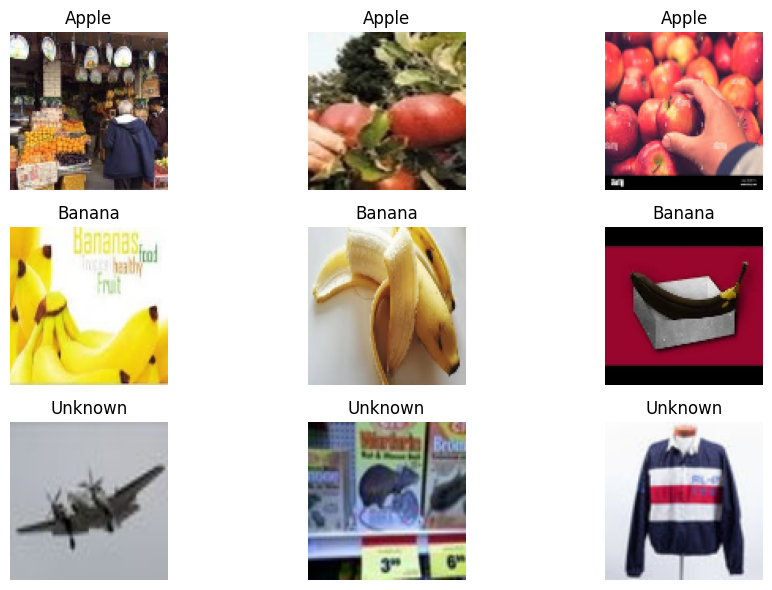

In [18]:
plt.figure(figsize=(10, 6))

classes = TARGET_CLASSES
images_per_class = 3

plot_index = 1

for class_name in classes:
    class_indices = np.where(y_train == class_name)[0][:images_per_class]

    for idx in class_indices:
        plt.subplot(len(classes), images_per_class, plot_index)
        plt.imshow(X_train[idx])
        plt.title(class_name)
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

## Step 12 — Encode class labels

In this step, I convered the text labels into numerical form so that they can be used by the CNN model.

The original labels are stored as class names:
- Apple
- Banana
- Unknown

These labels are first transformed into integer values using `LabelEncoder`. After that, they are converted into one-hot encoded vectors because the CNN model will use a softmax output layer for multi-class classification.

This step prepares the target labels in the correct format for training and evaluation.

In [19]:
label_encoder = LabelEncoder()

y_train_int = label_encoder.fit_transform(y_train)
y_val_int   = label_encoder.transform(y_val)
y_test_int  = label_encoder.transform(y_test)

print("Class to integer mapping:")
for class_name, class_id in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{class_name}: {class_id}")

y_train_encoded = to_categorical(y_train_int)
y_val_encoded   = to_categorical(y_val_int)
y_test_encoded  = to_categorical(y_test_int)

print("\nEncoded label shapes:")
print("y_train_encoded:", y_train_encoded.shape)
print("y_val_encoded  :", y_val_encoded.shape)
print("y_test_encoded :", y_test_encoded.shape)

Class to integer mapping:
Apple: 0
Banana: 1
Unknown: 2

Encoded label shapes:
y_train_encoded: (5820, 3)
y_val_encoded  : (120, 3)
y_test_encoded : (60, 3)


## Step 13 - Data augmentation strategy

In this step, I define a simple data augmentation pipeline for the training images.

Data augmentation helps improve generalization by creating slightly modified versions of the training images. This reduces the chance that the CNN will memorize the training set too closely.

For this project, I will apply light augmentation to the training data only:
- random horizontal flipping,
- small random rotations,
- and small random zoom changes.

The validation and test data will not be augmented because they should represent unseen data during evaluation.

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


## Step 14 - Build the CNN model

In this step, I build a baseline Convolutional Neural Network (CNN) for fruit classification.

The CNN is designed to learn image features in stages:
- Convolution layers extract patterns such as edges, textures, and shapes,
- Max pooling reduces the spatial dimensions while keeping the most important features,
- Dropout helps reduce overfitting,
- Global average pooling reduces the number of trainable parameters,
- Final dense layer with softmax produces class probabilities for the three classes.

This model uses three output classes:
- Apple
- Banana
- Unknown

In [22]:
cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    data_augmentation,
    
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Dropout(0.3),
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(3, activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,699 (397.26 KB)

 Trainable params: 101,699 (397.26 KB)

 Non-trainable params: 0 (0.00 B)

## Step 15 - Compile the model

In this step, I compile the CNN model by specifying:
- the optimizer (Adam),
- the loss function (categorical crossentropy),
- and the evaluation metric (accuracy).

The categorical crossentropy loss is used because this is a multi-class classification problem with one-hot encoded labels.

In [23]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Step 16 - Train the CNN model

In this step, I train the CNN model using the training dataset and evaluate its performance on the validation dataset.

Early stopping is used to prevent overfitting by stopping training when validation loss stops improving.

In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train, y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 27s 143ms/step - accuracy: 0.6110 - loss: 0.8523 - val_accuracy: 0.7000 - val_loss: 0.7214
Epoch 2/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - accuracy: 0.7247 - loss: 0.6900 - val_accuracy: 0.6667 - val_loss: 0.7845
Epoch 3/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.7466 - loss: 0.6169 - val_accuracy: 0.7750 - val_loss: 0.5233
Epoch 4/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 31s 169ms/step - accuracy: 0.7643 - loss: 0.5902 - val_accuracy: 0.7250 - val_loss: 0.7086
Epoch 5/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 30s 163ms/step - accuracy: 0.7689 - loss: 0.5778 - val_accuracy: 0.7000 - val_loss: 0.7268
Epoch 6/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 30s 165ms/step - accuracy: 0.7801 - loss: 0.5531 - val_accuracy: 0.8083 - val_loss: 0.5057
Epoch 7/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 29s 162ms/step - accuracy: 0.7911 - loss: 0.5178 - val_accuracy: 0.7000 - val_loss: 0.8445
Epoch 8/15
182/182 ━━━━━━━━━━━━━━━━━━━━ 32s 177ms/step - accuracy: 0.7905 - loss: 0

## Step 17 — Plot training and validation performance

In this step, I plot the training and validation accuracy and loss over each epoch.

These plots help me understand how the CNN model learned during training and whether signs of overfitting or underfitting are present.

- If training and validation accuracy improve together, the model is learning well.
- If training accuracy continues to increase while validation accuracy stops improving or decreases, this may indicate overfitting.
- If both accuracies remain low, the model may be underfitting.

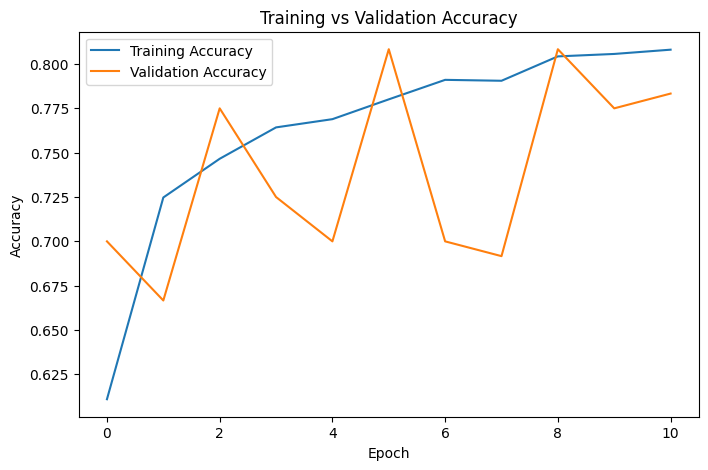

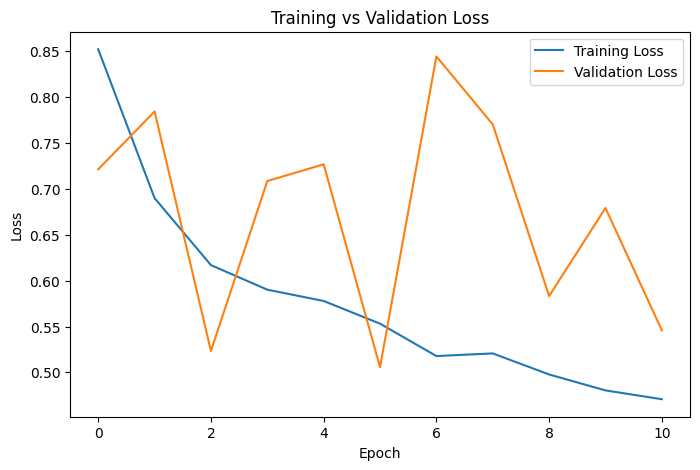

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Step 14B — Improved CNN model

In this step, I slightly improved the baseline CNN model to make training more stable.

The improvements include:
- Batch Normalization to stabilize learning,
- Dropout to reduce overfitting,
- Global Average Pooling to reduce the number of trainable parameters,
- and a slightly smaller learning rate for smoother optimization.

These changes are intended to improve generalization without making the model unnecessarily complex.

In [26]:
improved_cnn_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.35),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.35),

    layers.Dense(3, activation="softmax")
])

improved_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

## Step 15B — Compile the improved model

In this step, I compiled the improved CNN model.

I use:
- Adam optimizer with a smaller learning rate,
- categorical crossentropy loss,
- and accuracy as the main evaluation metric.

A smaller learning rate can help the model train more smoothly when the dataset is more varied.

In [27]:
improved_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved model compiled successfully.")

Improved model compiled successfully.


## Step 16B — Train the improved CNN model

In this step, I train the improved CNN model using early stopping and learning rate reduction.

- Early stopping prevents unnecessary training once validation performance stops improving.
- ReduceLROnPlateau lowers the learning rate automatically when validation loss stops improving, which can help the model converge more steadily.

In [28]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_improved = improved_cnn_model.fit(
    X_train, y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 45s 233ms/step - accuracy: 0.6792 - loss: 0.7636 - val_accuracy: 0.3333 - val_loss: 1.2515 - learning_rate: 5.0000e-04
Epoch 2/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - accuracy: 0.7459 - loss: 0.6153 - val_accuracy: 0.4667 - val_loss: 1.3188 - learning_rate: 5.0000e-04
Epoch 3/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 46s 252ms/step - accuracy: 0.7687 - loss: 0.5676 - val_accuracy: 0.7167 - val_loss: 0.6292 - learning_rate: 5.0000e-04
Epoch 4/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 47s 258ms/step - accuracy: 0.7832 - loss: 0.5283 - val_accuracy: 0.8000 - val_loss: 0.5654 - learning_rate: 5.0000e-04
Epoch 5/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 48s 266ms/step - accuracy: 0.8079 - loss: 0.4838 - val_accuracy: 0.6500 - val_loss: 1.0689 - learning_rate: 5.0000e-04
Epoch 6/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 48s 261ms/step - accuracy: 0.8186 - loss: 0.4600 - val_accuracy: 0.7917 - val_loss: 0.5091 - learning_rate: 5.0000e-04
Epoch 7/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 50s 27

## Step 17B — Plot the improved model performance

In this step, I plot the training and validation accuracy and loss for the improved CNN model.

These graphs help me check whether the model became more stable after adding Batch Normalization and learning rate control.

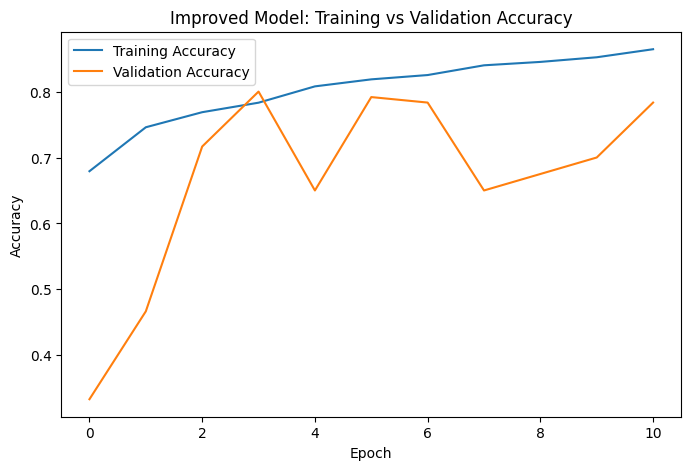

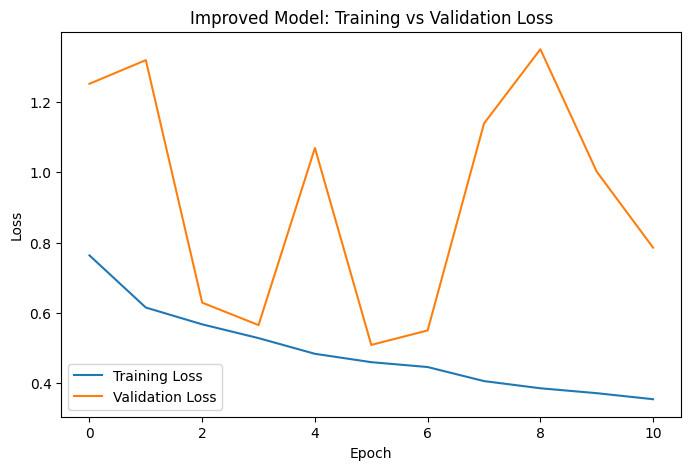

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history_improved.history["accuracy"], label="Training Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")
plt.title("Improved Model: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_improved.history["loss"], label="Training Loss")
plt.plot(history_improved.history["val_loss"], label="Validation Loss")
plt.title("Improved Model: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Step 18 — Evaluate the CNN model on the test set

In this step, I evaluate the trained CNN model on the test dataset.

I calculate:
- test accuracy,
- precision,
- recall,
- F1-score,
- confusion matrix,
- and a classification report.

These metrics provide a more complete evaluation of the model's classification performance across the three classes.

In [30]:
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test_encoded, verbose=0)

print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy, 4))

Test Loss     : 0.4368
Test Accuracy : 0.8167


In [31]:
y_pred_probs = cnn_model.predict(X_test)
y_pred_int = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test_int, y_pred_int)
precision = precision_score(y_test_int, y_pred_int, average="weighted")
recall = recall_score(y_test_int, y_pred_int, average="weighted")
f1 = f1_score(y_test_int, y_pred_int, average="weighted")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Accuracy : 0.8167
Precision: 0.8277
Recall   : 0.8167
F1-score : 0.8175


In [32]:
cm = confusion_matrix(y_test_int, y_pred_int)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_int, y_pred_int, target_names=label_encoder.classes_))

Confusion Matrix:
[[16  3  1]
 [ 2 18  0]
 [ 4  1 15]]

Classification Report:
              precision    recall  f1-score   support

       Apple       0.73      0.80      0.76        20
      Banana       0.82      0.90      0.86        20
     Unknown       0.94      0.75      0.83        20

    accuracy                           0.82        60
   macro avg       0.83      0.82      0.82        60
weighted avg       0.83      0.82      0.82        60



## Step 19 — Visualize the confusion matrix

In this step, I visualize the confusion matrix using a heatmap.

The confusion matrix shows how well the model performs on each class by comparing:
- the true labels (rows),
- and the predicted labels (columns).

A good model will have most values along the diagonal, indicating correct predictions.

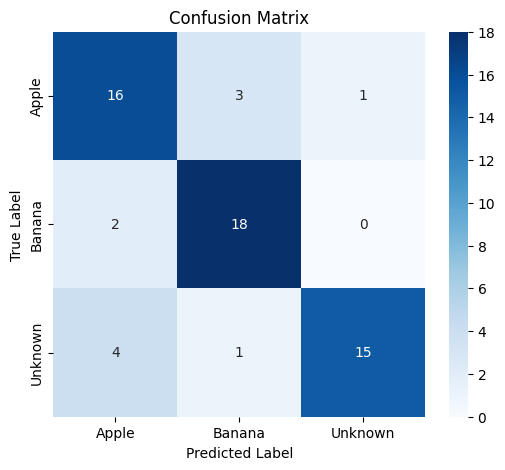

In [33]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Use your test labels
y_true = y_test_int
y_pred = y_pred_int

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Step 20 - Saving the model

In [37]:
model_path =  "saved_models/FRUIT_CLASSIFICATION_CNN_MODEL.h5"
cnn_model.save(model_path)

print("Model saved successfully at:", model_path)

Model saved successfully at: saved_models/FRUIT_CLASSIFICATION_CNN_MODEL.h5


## Step 21 — Live detection

In this step, A live detection can be done my using the droidcam app on mobile phone

In [ ]:
import cv2
import numpy as np
import tensorflow as tf

# Replace with your actual DroidCam IP shown on your phone
STREAM_URL = "http://10.0.0.48:4747/video"

# Load your trained CNN model
model = tf.keras.models.load_model("saved_models/FRUIT_CLASSIFICATION_CNN_MODEL.h5")

# Use your current project classes
class_names = ["Apple", "Banana", "Unknown"]

# Must match the image size used in training
IMG_SIZE = (100, 100)

def preprocess_frame(frame, img_size):
    # Convert BGR (OpenCV) to RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Resize to model input size
    resized = cv2.resize(rgb, img_size)

    # Normalize to [0,1]
    x = resized.astype("float32") / 255.0

    # Add batch dimension
    x = np.expand_dims(x, axis=0)
    return x

cap = cv2.VideoCapture(STREAM_URL)

if not cap.isOpened():
    print("Could not open DroidCam stream.")
else:
    print("Camera OK")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to read frame.")
        break

    # Preprocess the current frame
    x = preprocess_frame(frame, IMG_SIZE)

    # Predict
    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    confidence = float(np.max(probs))

    label = class_names[pred_idx]
    text = f"{label} ({confidence:.2%})"

    # Draw prediction on frame
    cv2.putText(
        frame,
        text,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.imshow("Live Fruit Detection", frame)

    # Press q to quit
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Camera OK
Failed to read frame.


[http @ 0x16bdb95a0] Stream ends prematurely at 136884904, should be 18446744073709551615


: 